## Test eigenvalues spectrum

In [1]:
import pennylane as qml
import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from scipy.linalg import expm

2025-10-29 22:39:43.768376: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 22:39:43.771368: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 22:39:43.780052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761773983.793535   77004 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761773983.797525   77004 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761773983.808379   77004 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Pick a sample image

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_ones = x_train[y_train == 2]
x_train_ones_32 = np.pad(x_train_ones, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image = x_train_ones_32[0]


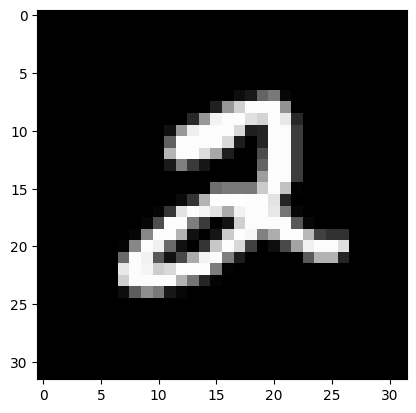

In [3]:
plt.imshow(Image, cmap='gray')
plt.show()

## Prepare the sample as unitary operator

In [4]:
Img = np.cov(Image/255.0)
O = expm(1j * Img)

## Compute the eigenvalues

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(Img)
d_l_m = pd.DataFrame(eigenvalues, columns=['Eigenvalues'] )
display(d_l_m)

,Eigenvalues
0,1.022884
1,0.438248
2,0.269696
3,0.227593
4,0.126949
5,0.070116
6,0.029818
7,0.009372
8,0.007113
9,0.006120


In [6]:
eigenvalues, eigenvectors = np.linalg.eig(O)
d_l = pd.DataFrame(eigenvalues, columns=['Eigenvalues'] )
display(d_l)

,Eigenvalues
0,0.520906+0.853614j
1,0.905497+0.424354j
2,0.963852+0.266439j
3,0.974212+0.225633j
4,0.991953+0.126608j
5,0.997543+0.070059j
6,0.999555+0.029814j
7,0.999956+0.009372j
8,0.999975+0.007113j
9,0.999981+0.006120j


In [7]:
d_l_p = pd.DataFrame(np.angle(eigenvalues), columns=['Eigenvalues'] )
display(d_l_p)

,Eigenvalues
0,1.022884
1,0.438248
2,0.269696
3,0.227593
4,0.126949
5,0.070116
6,0.029818
7,0.009372
8,0.007113
9,0.006120


In [8]:
d_q = pd.DataFrame(eigenvectors)
display(d_q)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
4,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.000000j,-0.000000+0.000000j,0.000000-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,-0.000000+0.000000j,...,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
7,0.062384+0.000000j,-0.060088+0.000000j,-0.013558-0.000000j,0.044806-0.000000j,-0.062985-0.000000j,0.181323+0.000000j,-0.148153-0.000000j,-0.249816+0.000000j,-0.339053-0.000000j,0.147193+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
8,0.258832-0.000000j,-0.226796+0.000000j,0.159372-0.000000j,0.090985+0.000000j,-0.245707-0.000000j,0.211777+0.000000j,-0.023932-0.000000j,0.222552+0.000000j,-0.199131+0.000000j,0.016461+0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
9,0.350219-0.000000j,-0.138196+0.000000j,0.164184+0.000000j,-0.172754+0.000000j,-0.089541+0.000000j,0.131881+0.000000j,0.289689+0.000000j,0.008631-0.000000j,0.533567+0.000000j,-0.188687-0.000000j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j


## Eigenvectors

In [9]:
Identity = np.zeros((32, 32), dtype=complex)
for i in range(32):
    Identity += np.outer(eigenvectors[:, i], eigenvectors[:, i].conj())
print(Identity)
np.allclose(Identity, np.eye(32))

[[1.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 1.+0.j]]


True

### Orthogonality

In [10]:
Orthogonality_test = np.zeros((32, 32), dtype=complex)

for i in range(32):
    for j in range(32):
        Orthogonality_test[i][j] = eigenvectors[:, i].conj().T@eigenvectors[:, j]
print(np.real(Orthogonality_test))
np.allclose(Orthogonality_test, np.eye(32))

[[ 1.00000000e+00  8.67361738e-19  1.08853898e-16 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 8.67361738e-19  1.00000000e+00 -2.15105711e-16 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.08853898e-16 -2.15105711e-16  1.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  1.00000000e+00]]


True

In [11]:
display(d_q[0])

0    -0.000000+0.000000j
1    -0.000000+0.000000j
2    -0.000000+0.000000j
3    -0.000000+0.000000j
4    -0.000000+0.000000j
5    -0.000000+0.000000j
6    -0.000000+0.000000j
7     0.062384+0.000000j
8     0.258832-0.000000j
9     0.350219-0.000000j
10    0.344579+0.000000j
11    0.317283+0.000000j
12    0.273668+0.000000j
13    0.178707-0.000000j
14    0.163325+0.000000j
15    0.234322-0.000000j
16    0.316760+0.000000j
17    0.375079+0.000000j
18    0.311432-0.000000j
19    0.233446-0.000000j
20    0.035951+0.000000j
21    0.036416+0.000000j
22    0.049752-0.000000j
23   -0.022380-0.000000j
24   -0.023318-0.000000j
25   -0.000000+0.000000j
26   -0.000000+0.000000j
27   -0.000000+0.000000j
28   -0.000000+0.000000j
29   -0.000000+0.000000j
30   -0.000000+0.000000j
31   -0.000000+0.000000j
Name: 0, dtype: complex128

In [12]:
display(d_q[1])

0     0.000000+0.000000j
1     0.000000+0.000000j
2     0.000000+0.000000j
3     0.000000+0.000000j
4     0.000000+0.000000j
5     0.000000+0.000000j
6     0.000000+0.000000j
7    -0.060088+0.000000j
8    -0.226796+0.000000j
9    -0.138196+0.000000j
10    0.105484-0.000000j
11    0.199732-0.000000j
12    0.197481-0.000000j
13   -0.035384-0.000000j
14   -0.123389-0.000000j
15   -0.159717+0.000000j
16   -0.111800+0.000000j
17    0.045920+0.000000j
18   -0.019819-0.000000j
19    0.029915-0.000000j
20    0.205780-0.000000j
21    0.411337+0.000000j
22    0.585674+0.000000j
23    0.455275-0.000000j
24    0.126972-0.000000j
25    0.000000+0.000000j
26    0.000000+0.000000j
27    0.000000+0.000000j
28    0.000000+0.000000j
29    0.000000+0.000000j
30    0.000000+0.000000j
31    0.000000+0.000000j
Name: 1, dtype: complex128

In [13]:
np.abs(eigenvectors[:, 0].conj().T@eigenvectors[:, 1])

np.float64(4.8044308350988195e-17)

In [14]:
dev = qml.device("default.qubit", wires=10) # shots=1000

def powm(M,p):
    if p == 0:
        return M
    T = M@M
    for i in range(1,p):
        T = T@T
    return T

@qml.qnode(dev)
def ImageEigen(image, option=True):
    P1 = np.array([[0,0],[0,1]])
    for i in range(5):
        qml.Hadamard(wires=i)
    for i in range(5,10):
        qml.Hadamard(wires=i)
    for i in range(5):
        qml.ctrl(qml.QubitUnitary(powm(image,i), wires=range(5,10)), control=4-i)
    qml.adjoint(qml.QFT(wires=range(5)))
    H = np.kron(np.kron(P1,P1),np.eye(2**3))
    #if option:
    #    return [qml.probs(op= qml.Hermitian(H,wires=range(5))),qml.probs(wires=range(5,10))]
    #else:
    return qml.expval(qml.Hermitian(H,wires=range(5)))

(<Figure size 1000x1100 with 1 Axes>, <Axes: >)


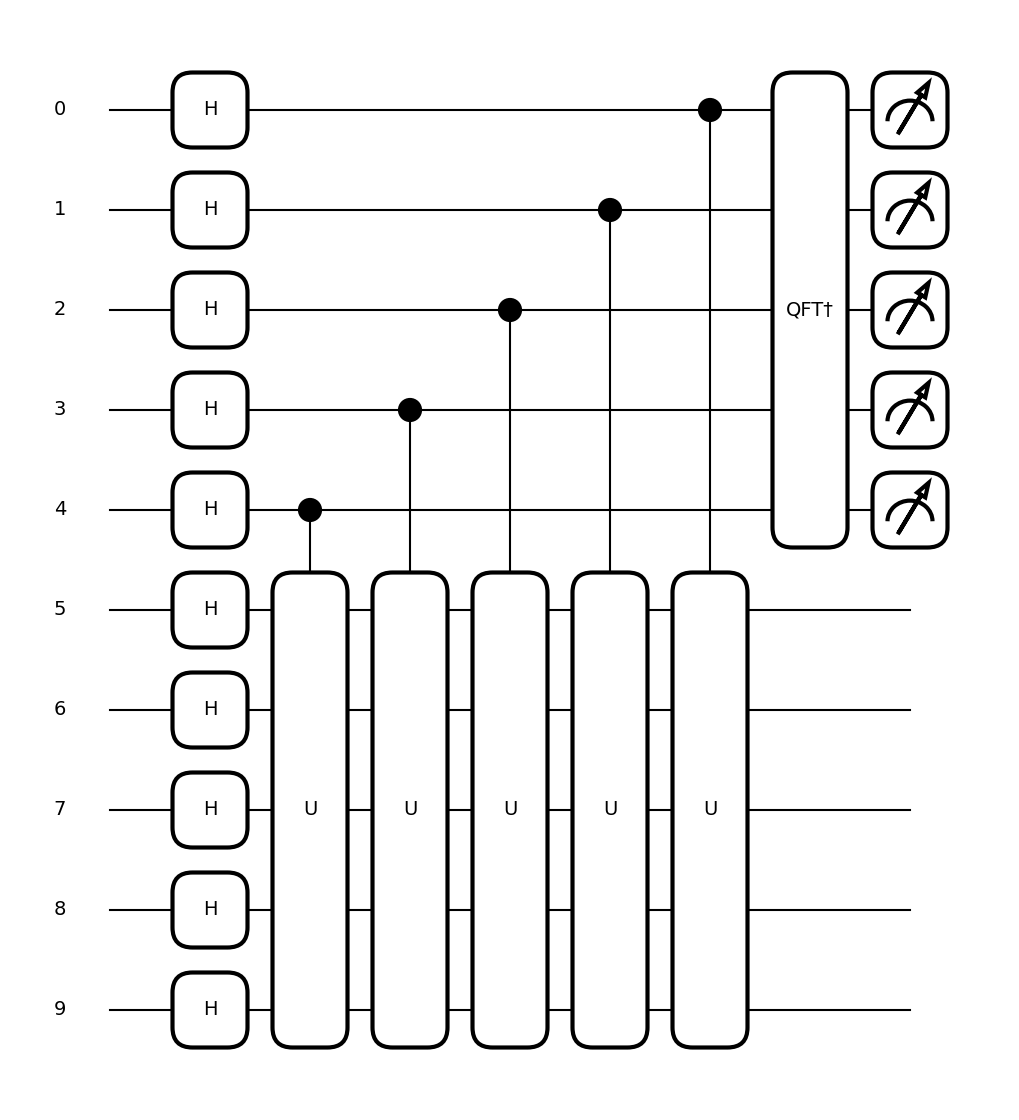

In [15]:
circuit = qml.QNode(ImageEigen,dev)
print(qml.draw_mpl(circuit)(O))

In [16]:
#l,q = circuit(O)

In [17]:
e = circuit(O,False)
e

np.float64(0.008377899057776726)

In [18]:
# bit_strings = [f"{x:0{5}b}" for x in range(len(e))]
# plt.bar(bit_strings, l)
# plt.xticks(rotation=90)

In [19]:
dev = qml.device("default.qubit", wires=10)
@qml.qnode(dev)
def ImageEigen2(image):
    P1 = np.array([[0,0],[0,1]])
    for i in range(5):
        qml.Hadamard(wires=i)
    for i in range(5,10):
        qml.Hadamard(wires=i)
    qml.ControlledSequence(qml.QubitUnitary(image, wires=range(5,10)),control=range(5))
    qml.adjoint(qml.QFT(wires=range(5)))
    H = np.kron(np.kron(P1,P1),np.eye(2**3))
    return qml.expval(qml.Hermitian(H,wires=range(5)))

(<Figure size 600x1100 with 1 Axes>, <Axes: >)


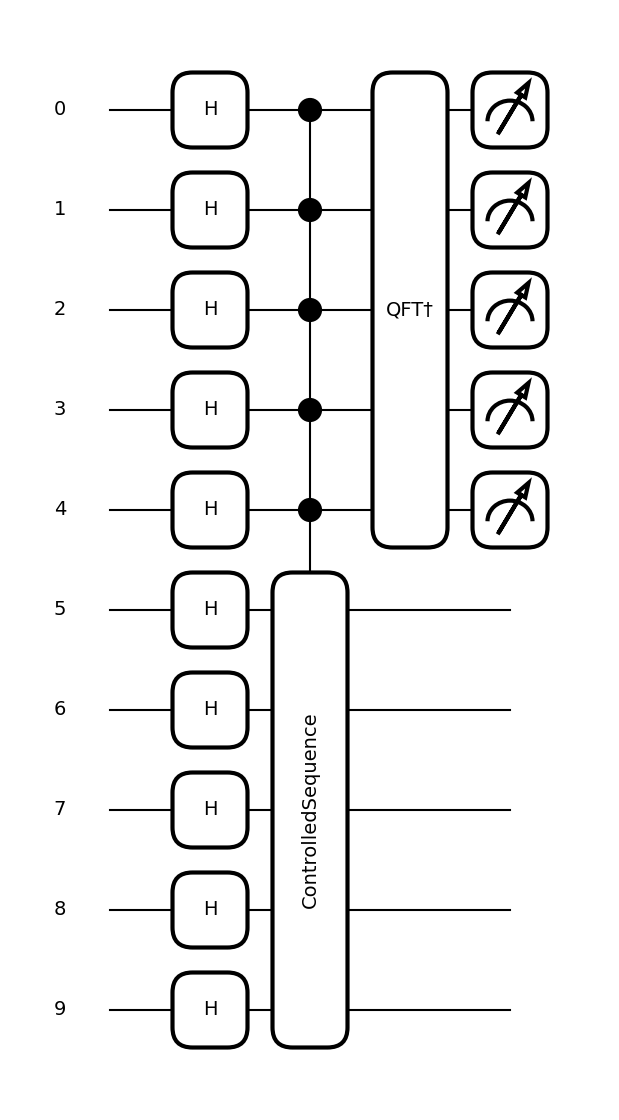

In [20]:
circuit = qml.QNode(ImageEigen2,dev)
print(qml.draw_mpl(circuit)(O))
l = circuit(O)


In [21]:
print(l)

0.008377899057776726


In [22]:
bit_strings = [f"{x:0{7}b}" for x in range(len(l))]
plt.bar(bit_strings, l)
plt.xticks(rotation=90)

TypeError: object of type 'numpy.float64' has no len()